In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/multitask_preplay/figures
changing to root directory
at directory: /Users/wilka/git/research/multitask_preplay


In [3]:
sys.path.append("simulations")
sys.path.append("figures")

In [4]:
from experiments.craftax.craftax_fullmap_renderer import TEXTURES

Loading textures from cache.
Textures successfully loaded from cache.
Cache dir: /Users/wilka/git/research/multitask_preplay/experiments/craftax/craftax_cache
regular map cache already exists in craftax library
full map cache already exists in craftax library
Loading textures from cache.
Textures successfully loaded from cache.


In [5]:
from craftax_cogsci_envs import (
  make_craftax_env,
  visualize_simplified_block_config,
  save_figure,
)
import craftax_experiment_configs
from craftax.craftax.constants import BlockType

In [6]:
jax_env = make_craftax_env()

In [7]:
def get_block_locations(world_seed, blocks, state=None):
  for block in blocks:
    if state is None:
      params = default_params.replace(
        world_seeds=(world_seed,),
      )
      obs, state = jax_env.reset(key, params)
    locations = craftax_utils.get_object_positions(state, block)
    print(f"{block.name} locations: {locations}")

(0.33725490196078434, 0.7058823529411765, 0.9137254901960784) red
Loading path from cache: /Users/wilka/git/research/multitask_preplay/simulations/craftax_cache/paths/world_20_path_(18, 30)_(13, 13).npy
Loading path from cache: /Users/wilka/git/research/multitask_preplay/simulations/craftax_cache/paths/world_20_path_(18, 30)_(40, 32).npy
Loading path from cache: /Users/wilka/git/research/multitask_preplay/simulations/craftax_cache/paths/world_20_path_(18, 30)_(42, 30).npy
Saved to /Users/wilka/git/research/multitask_preplay/simulations/craftax_cache/world_20_paths.png


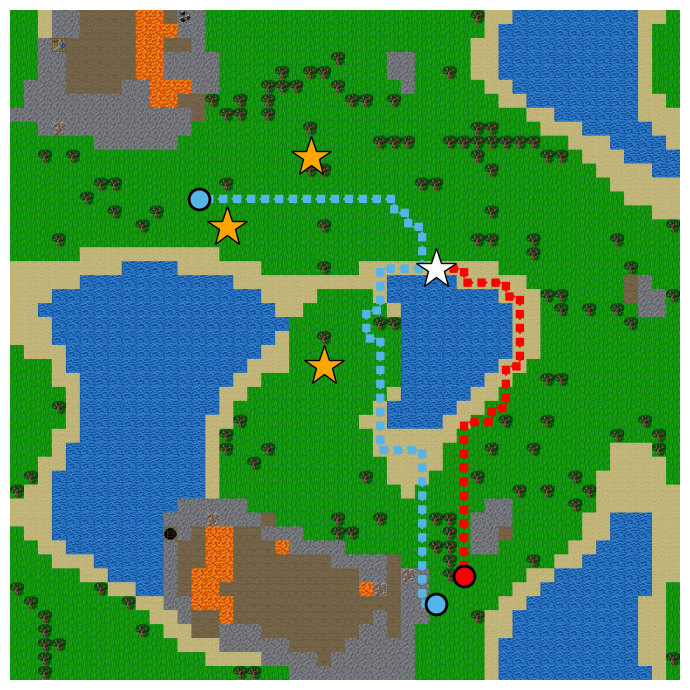

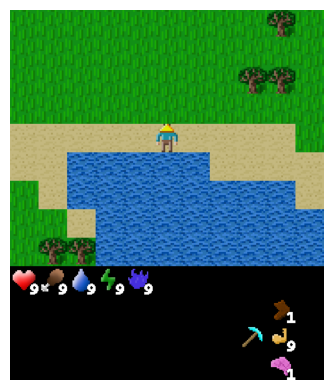

Saved figure to ../preplay_results/env_figures/craftax/2_fullmap.pdf
Saved figure to ../preplay_results/env_figures/craftax/2_agentmap.pdf


In [19]:
i = 2
fig1, fig2 = visualize_simplified_block_config(
  craftax_experiment_configs.PATHS_CONFIGS[i], jax_env
)

# Display inline before saving (save_figure closes them)
display(fig1)
display(fig2)

save_figure(fig1, f"{i}_fullmap")
save_figure(fig2, f"{i}_agentmap")

# Path to end + what agent sees at end

Loading path from cache: /Users/wilka/git/research/multitask_preplay/simulations/craftax_cache/paths/world_20_path_(18, 30)_(42, 30).npy


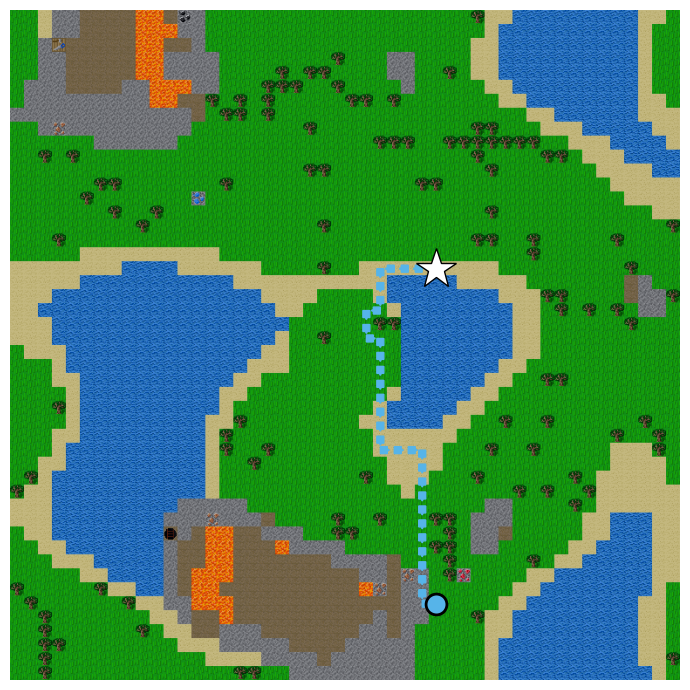

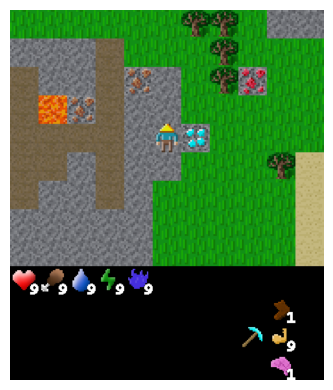

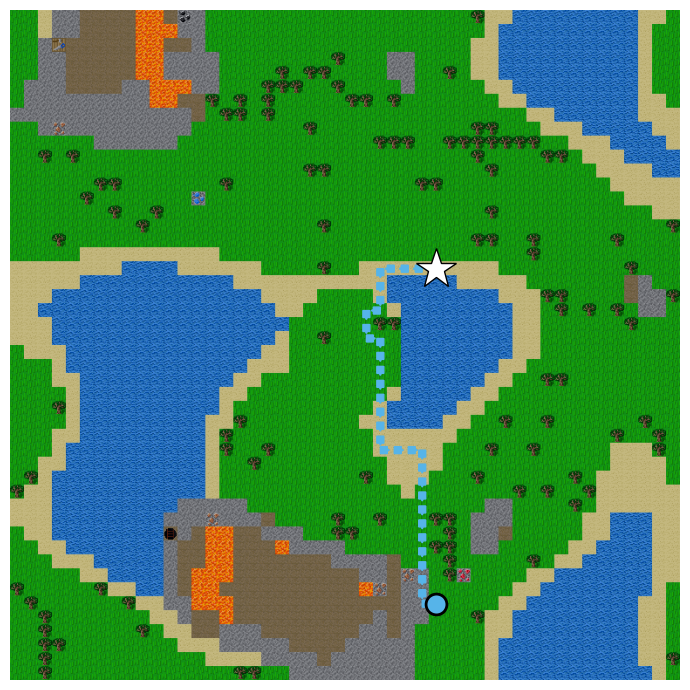

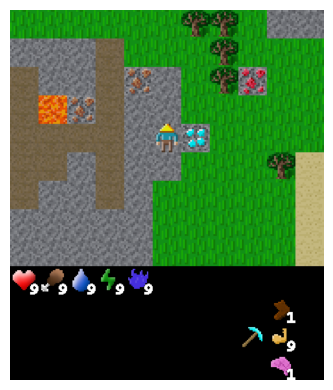

In [26]:
import numpy as np
import jax
import plot_configs
import matplotlib.pyplot as plt
import craftax_utils
from craftax.craftax.renderer import (
  render_craftax_pixels as render_craftax_pixels_partial,
)
from experiments.craftax.craftax_fullmap_renderer import (
  render_craftax_pixels as render_craftax_pixels_full,
)
import experiments.craftax.craftax_fullmap_constants as constants

config = craftax_experiment_configs.PATHS_CONFIGS[2]
train_color = plot_configs.TRAIN_COLOR

# --- Setup environment parameters ---
goal_objects = np.concatenate((config.train_objects, config.test_objects))
goal_locations = (
  config.train_object_location,
  config.test_object_location,
)
if config.train_distractor_object_location is not None:
  goal_locations = (
    config.train_object_location,
    config.train_distractor_object_location,
    config.test_object_location,
  )

env_params = jax_env.default_params.replace(
  world_seeds=(config.world_seed,),
  max_timesteps=100000,
  goal_locations=goal_locations,
  placed_goals=goal_objects,
)
key = jax.random.PRNGKey(0)

# --- Figure 1: Train Path Only ---
fig_path, ax_path = plt.subplots(figsize=(7, 7))

# Reset env with eval start position
start_position = config.start_eval_positions[0]
_obs, state = jax_env.reset(key, env_params.replace(start_positions=(start_position,)))

# Render full map
image = render_craftax_pixels_full(
  state, block_pixel_size=constants.BLOCK_PIXEL_SIZE_IMG, show_agent=False
).astype(np.uint8)
ax_path.imshow(image)

# Draw only the train path using draw_object_path logic
train_object = BlockType(config.train_objects[0])
path = craftax_utils.draw_object_path(
  state=state,
  object_type=train_object,
  start_position=start_position,
  color=train_color,
  ax=ax_path,
  image=image,
  world_seed=config.world_seed,
  show_path_length=False,
  arrow_scale=10,
  line_thickness=10.0,
)

# Place start marker
craftax_utils.place_start_marker(ax_path, start_position, state, image, marker_size=30)

# Place goal marker for train object
train_goal_positions = craftax_utils.get_object_positions(state, train_object)
if len(train_goal_positions) > 0:
  craftax_utils.place_goal_marker(
    ax_path, train_goal_positions[0], state, image, train_color, marker_size=15
  )

ax_path.axis("off")
plt.tight_layout()

# --- Figure 2: Partial view when agent is next to the train object ---
fig_view, ax_view = plt.subplots(figsize=(4, 4))

# Get train object location and shift x by -1 (to the left)
train_obj_loc = config.train_object_location
agent_view_pos = (train_obj_loc[0], train_obj_loc[1] - 1)

# Reset environment with agent at the view position
render_env_params = env_params.replace(
  start_positions=(agent_view_pos,),
)
_obs_render, state_render = jax_env.reset(key, render_env_params)

# Render partial observation (what agent sees)
BLOCK_PIXEL_SIZE_HUMAN = 64
agent_view = render_craftax_pixels_partial(
  state_render, block_pixel_size=BLOCK_PIXEL_SIZE_HUMAN
).astype(np.uint8)

ax_view.imshow(agent_view)
ax_view.axis("off")
plt.tight_layout()

display(fig_path)
display(fig_view)

In [9]:
world_seed = 3
start_position = (28, 25)

get_block_locations(
  world_seed, blocks=[BlockType.DIAMOND, BlockType.CRAFTING_TABLE, BlockType.IRON]
)
train_object = BlockType.SAPPHIRE
train_object_location = (39, 44)  # replacing old diamond location

train_distractor_object = BlockType.RUBY
train_distractor_object_location = (35, 13)

test_object = BlockType.DIAMOND
test_object_location = (37, 47)


craftax_utils.train_test_paths(
  jax_env=jax_env,
  params=default_params,
  world_seed=world_seed,
  start_position=start_position,
  train_object=train_object,
  train_distractor_object=train_distractor_object,
  test_object=test_object,
  train_object_location=train_object_location,
  train_distractor_object_location=train_distractor_object_location,
  test_object_location=test_object_location,
  prefix="single",
  extra_start_positions_rng=jax.random.PRNGKey(42),
  extra_start_position_center=(20, 24),
  extra_positions=[(32, 30), (17, 28), (29, 15)],
  # extra_start_positions=3,
)
# get_block_locations(
#     world_seed,
#     blocks=[BlockType.DIAMOND, BlockType.SAPPHIRE, BlockType.RUBY],
#     state=state,
#     )

NameError: name 'default_params' is not defined

In [10]:
world_seed = 15
# start_position=(22, 25)
start_position = None
get_block_locations(
  world_seed, blocks=[BlockType.DIAMOND, BlockType.CRAFTING_TABLE, BlockType.IRON]
)
train_object = BlockType.SAPPHIRE
train_object_location = (41, 44)  # replacing old diamond location

train_distractor_object = BlockType.RUBY
train_distractor_object_location = (37, 13)

test_object = BlockType.DIAMOND
test_object_location = (38, 46)


craftax_utils.train_test_paths(
  jax_env=jax_env,
  params=default_params,
  world_seed=world_seed,
  start_position=start_position,
  train_object=train_object,
  train_distractor_object=train_distractor_object,
  test_object=test_object,
  train_object_location=train_object_location,
  train_distractor_object_location=train_distractor_object_location,
  test_object_location=test_object_location,
  prefix="single",
  extra_start_positions_rng=jax.random.PRNGKey(42),
  extra_start_position_center=(20, 25),
  extra_positions=craftax_experiment_configs.PATHS_CONFIGS[1].start_train_positions,
)
# get_block_locations(
#     world_seed,
#     blocks=[BlockType.DIAMOND, BlockType.SAPPHIRE, BlockType.RUBY],
#     state=state,
#     )

NameError: name 'default_params' is not defined

In [11]:
world_seed = 20
start_position = (18, 30)
# start_position = None
get_block_locations(
  world_seed, blocks=[BlockType.DIAMOND, BlockType.CRAFTING_TABLE, BlockType.IRON]
)
train_object = BlockType.SAPPHIRE
train_object_location = (42, 30)  # replacing old diamond location

train_distractor_object = BlockType.RUBY
train_distractor_object_location = (13, 13)

test_object = BlockType.DIAMOND
test_object_location = (40, 32)


craftax_utils.train_test_paths(
  jax_env=jax_env,
  params=default_params,
  world_seed=world_seed,
  start_position=start_position,
  train_object=train_object,
  train_distractor_object=train_distractor_object,
  test_object=test_object,
  train_object_location=train_object_location,
  train_distractor_object_location=train_distractor_object_location,
  test_object_location=test_object_location,
  prefix="single",
  extra_start_positions_rng=jax.random.PRNGKey(42),
  extra_start_position_center=(20, 25),
  extra_positions=craftax_experiment_configs.PATHS_CONFIGS[2].start_train_positions,
)
# get_block_locations(
#     world_seed,
#     blocks=[BlockType.DIAMOND, BlockType.SAPPHIRE, BlockType.RUBY],
#     state=state,
#     )

NameError: name 'default_params' is not defined

In [12]:
world_seed = 95
start_position = (7, 16)

get_block_locations(
  world_seed, blocks=[BlockType.DIAMOND, BlockType.CRAFTING_TABLE, BlockType.IRON]
)
train_object = BlockType.SAPPHIRE
train_object_location = (3, 36)  # replacing old diamond location

train_distractor_object = BlockType.RUBY
train_distractor_object_location = (17, 13)

test_object = BlockType.DIAMOND
test_object_location = (6, 34)


craftax_utils.train_test_paths(
  jax_env=jax_env,
  params=default_params,
  world_seed=world_seed,
  start_position=start_position,
  train_object=train_object,
  train_distractor_object=train_distractor_object,
  test_object=test_object,
  train_object_location=train_object_location,
  train_distractor_object_location=train_distractor_object_location,
  test_object_location=test_object_location,
  prefix="single",
  extra_start_positions_rng=jax.random.PRNGKey(42),
  extra_start_position_center=(20, 25),
  extra_positions=craftax_experiment_configs.PATHS_CONFIGS[3].start_train_positions,
)
# get_block_locations(
#     world_seed,
#     blocks=[BlockType.DIAMOND, BlockType.SAPPHIRE, BlockType.RUBY],
#     state=state,
#     )

NameError: name 'default_params' is not defined

In [14]:
world_seed = 2
start_position = (34, 10)
import jax

# start_position = None
with jax.disable_jit():
  craftax_utils.train_test_paths(
    jax_env=jax_env,
    params=default_params,
    world_seed=world_seed,
    start_position=start_position,
    train_object=BlockType.CRAFTING_TABLE,
    test_object=BlockType.DIAMOND,
    prefix="double",
    nearby_goal=False,
    extra_start_positions_rng=jax.random.PRNGKey(42),
    extra_start_position_center=(1, 15),
  )

NameError: name 'craftax_utils' is not defined

A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_2_path_(46, 18)_(41, 29).npy


A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_2_path_(46, 18)_(34, 27).npy
path length: 17
path length: 26


A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_2_path_(46, 18)_(41, 8).npy


A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_2_path_(46, 18)_(37, 28).npy
path length: 16
path length: 20
Saved to craftax_cache/0double/world_2_paths.png


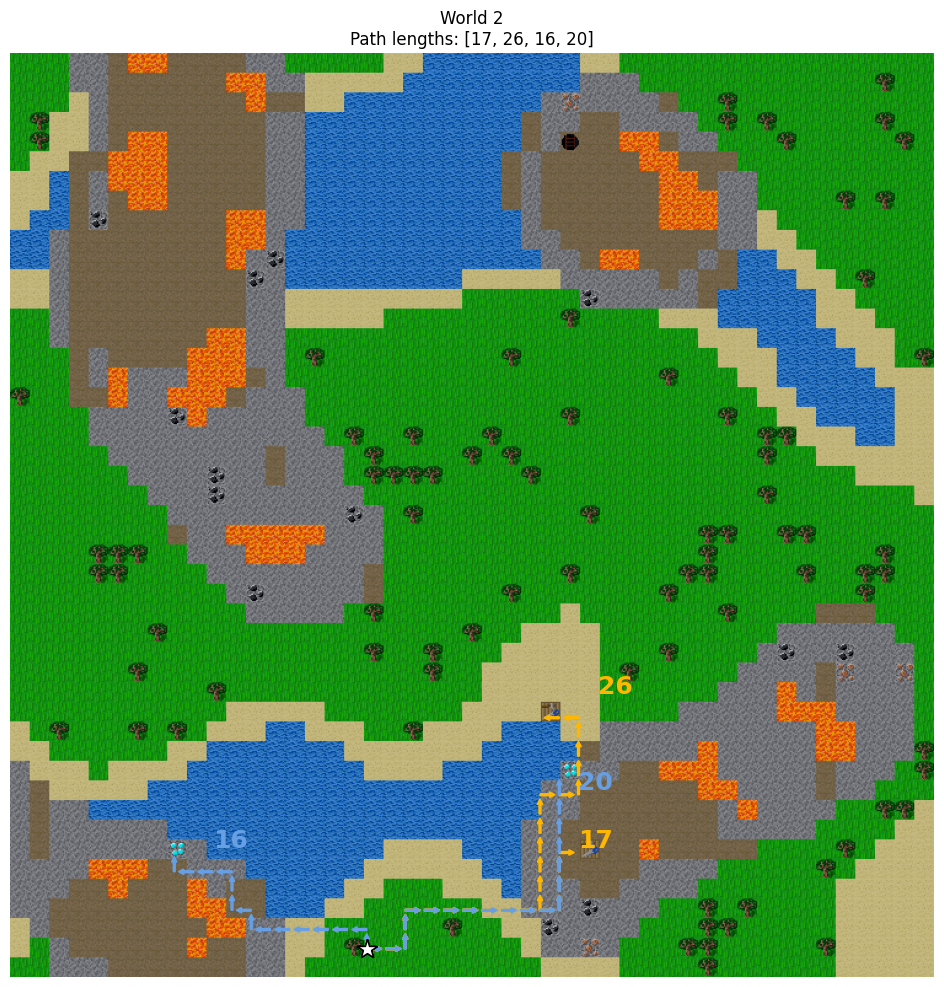

In [125]:
world_seed = 2
start_position = (46, 18)
# start_position = None
with jax.disable_jit():
  craftax_utils.train_test_paths(
    jax_env,
    params,
    world_seed,
    start_position,
    BlockType.CRAFTING_TABLE,
    BlockType.DIAMOND,
    "double",
    nearby_goal=False,
    extra_start_positions_rng=jax.random.PRNGKey(42),
    extra_start_position_center=(1, 15),
  )

In [80]:
world_seed = 13
start_position = (14, 5)
# start_position = None
with jax.disable_jit():
  craftax_utils.train_test_paths(
    jax_env,
    params,
    world_seed,
    start_position,
    BlockType.CRAFTING_TABLE,
    BlockType.DIAMOND,
    "double",
    nearby_goal=False,
    extra_start_positions_rng=jax.random.PRNGKey(42),
    extra_start_position_center=(1, 15),
  )

NameError: name 'params' is not defined

A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_16_path_(46, 26)_(18, 23).npy


A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_16_path_(46, 26)_(18, 18).npy
path length: 32
path length: 37


A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_16_path_(46, 26)_(21, 35).npy


A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_16_path_(46, 26)_(14, 21).npy
path length: 35
path length: 38
Saved to craftax_cache/0double/world_16_paths.png


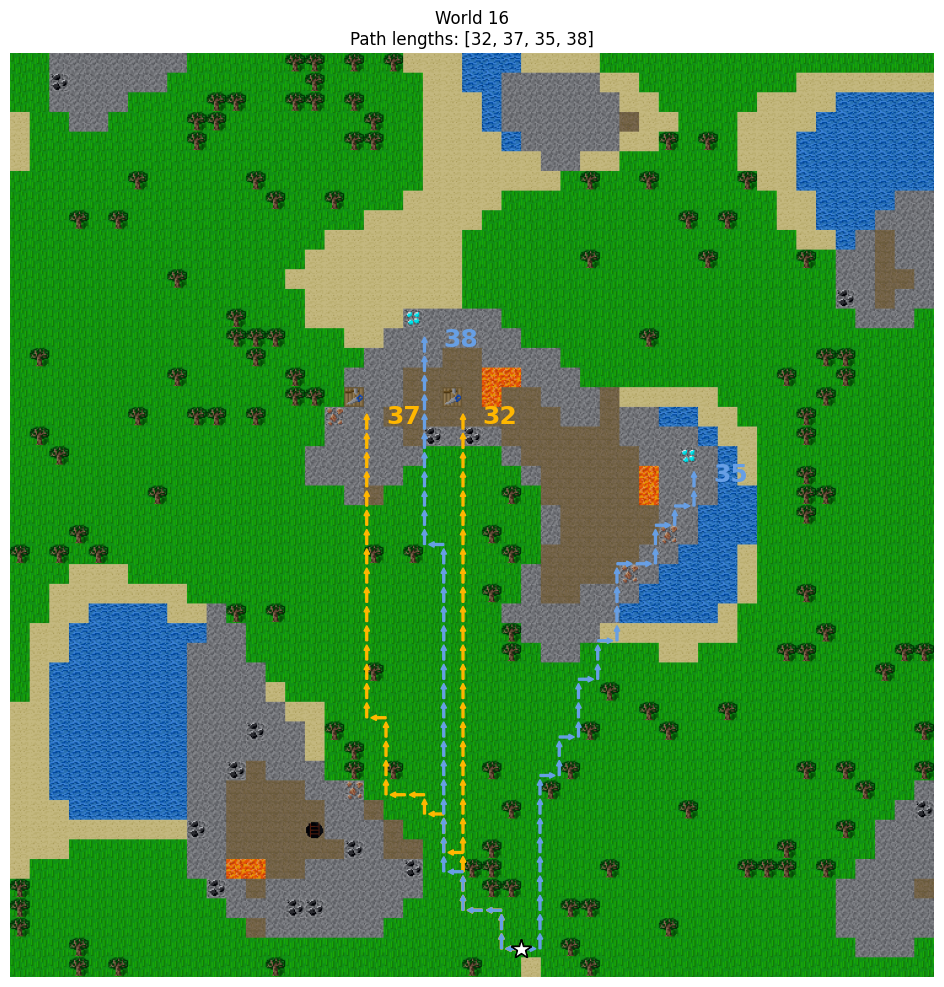

In [134]:
world_seed = 16
start_position = (46, 26)
# start_position = None
with jax.disable_jit():
  craftax_utils.train_test_paths(
    jax_env,
    params,
    world_seed,
    start_position,
    BlockType.CRAFTING_TABLE,
    BlockType.DIAMOND,
    "double",
    nearby_goal=False,
    extra_start_positions_rng=jax.random.PRNGKey(42),
    extra_start_position_center=(1, 15),
  )

A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_21_path_(25, 24)_(12, 36).npy


A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_21_path_(25, 24)_(19, 43).npy
path length: 26
path length: 26


A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_21_path_(25, 24)_(32, 38).npy


A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_21_path_(25, 24)_(16, 39).npy
path length: 22
path length: 25
Saved to craftax_cache/0double/world_21_paths.png


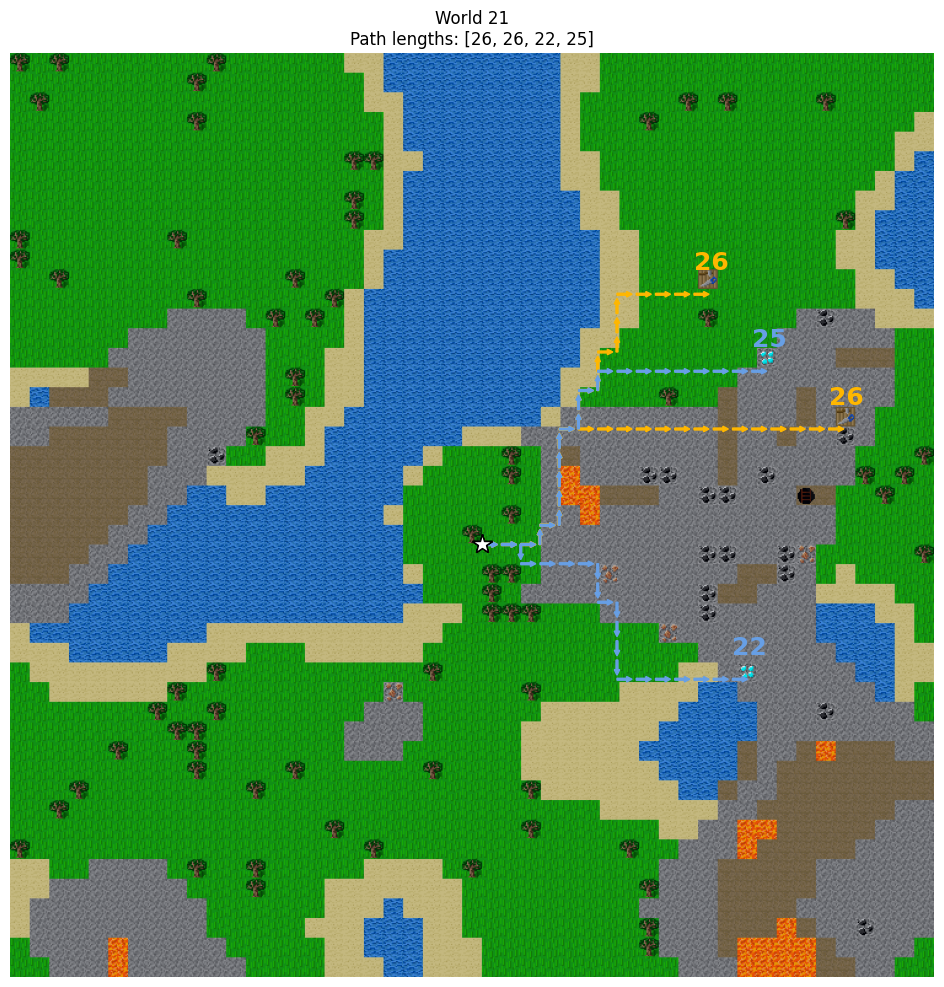

In [136]:
world_seed = 21
start_position = (25, 24)
# start_position = None
with jax.disable_jit():
  craftax_utils.train_test_paths(
    jax_env,
    params,
    world_seed,
    start_position,
    BlockType.CRAFTING_TABLE,
    BlockType.DIAMOND,
    "double",
    nearby_goal=False,
    extra_start_positions_rng=jax.random.PRNGKey(42),
    extra_start_position_center=(1, 15),
  )

In [16]:
world_seed = 38
start_position = (38, 24)
# start_position = None
import craftax_utils

with jax.disable_jit():
  craftax_utils.train_test_paths(
    jax_env,
    params,
    world_seed,
    start_position,
    BlockType.CRAFTING_TABLE,
    BlockType.DIAMOND,
    "double",
    nearby_goal=False,
    extra_start_positions_rng=jax.random.PRNGKey(42),
    extra_start_position_center=(1, 15),
  )

NameError: name 'params' is not defined

A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_48_path_(26, 16)_(9, 44).npy


A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_48_path_(26, 16)_(9, 46).npy
path length: 46
path length: 48


A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_48_path_(26, 16)_(32, 46).npy


A* Iterations: 0it [00:00, ?it/s]

Saving path to cache: craftax_cache/0_paths/world_48_path_(26, 16)_(8, 43).npy
path length: 37
path length: 46
Saved to craftax_cache/0double/world_48_paths.png


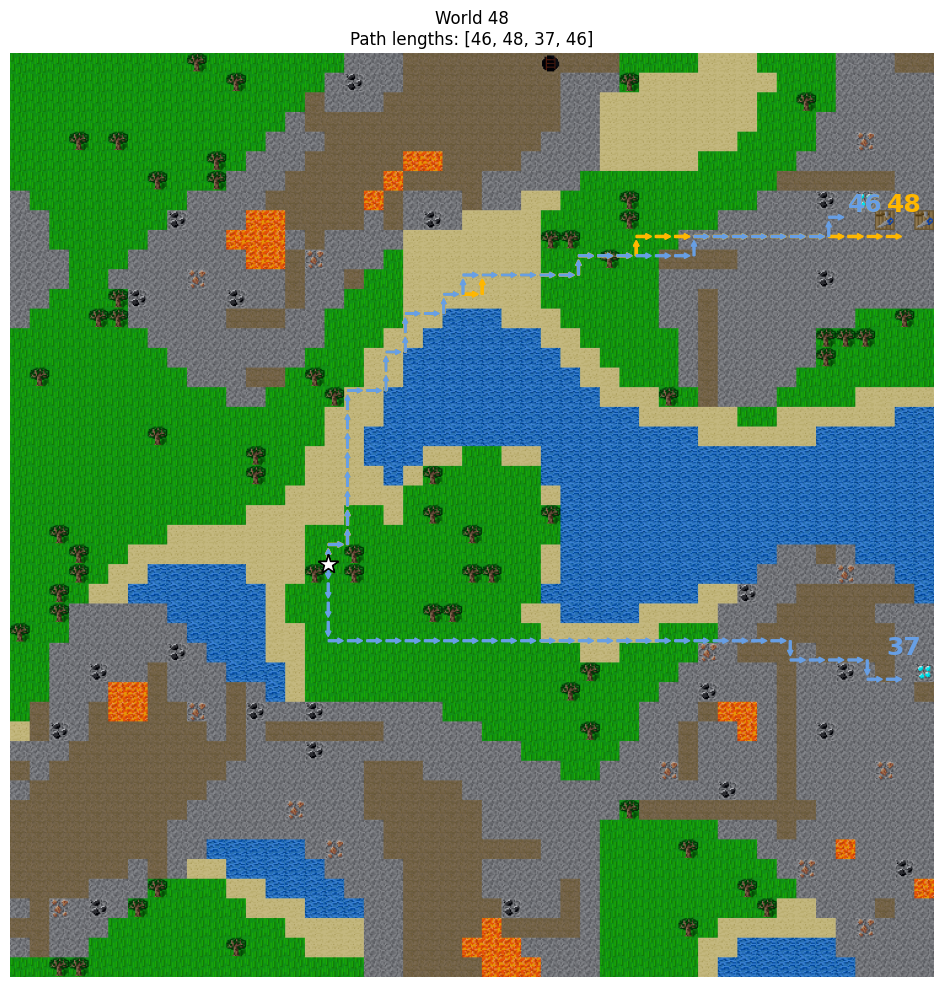

In [141]:
world_seed = 48
start_position = (26, 16)
# start_position = None
with jax.disable_jit():
  craftax_utils.train_test_paths(
    jax_env,
    params,
    world_seed,
    start_position,
    BlockType.CRAFTING_TABLE,
    BlockType.DIAMOND,
    "double",
    nearby_goal=False,
    extra_start_positions_rng=jax.random.PRNGKey(42),
    extra_start_position_center=(1, 15),
  )